### Notebook de testes para encontrar o melhor backtest do modelo

In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns


from funcoes import (
    pca_portfolio_spy,
    stats_from_returns,
)

In [7]:
# Carregar dados
data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
start_date = "1998-10-01"
end_date = "2007-12-31"

returns = returns.loc[start_date:end_date]
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True,axis=0, how='all')
returns_spy.dropna(inplace=True,axis=1, how='any')

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

[*********************100%***********************]  1 of 1 completed


Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

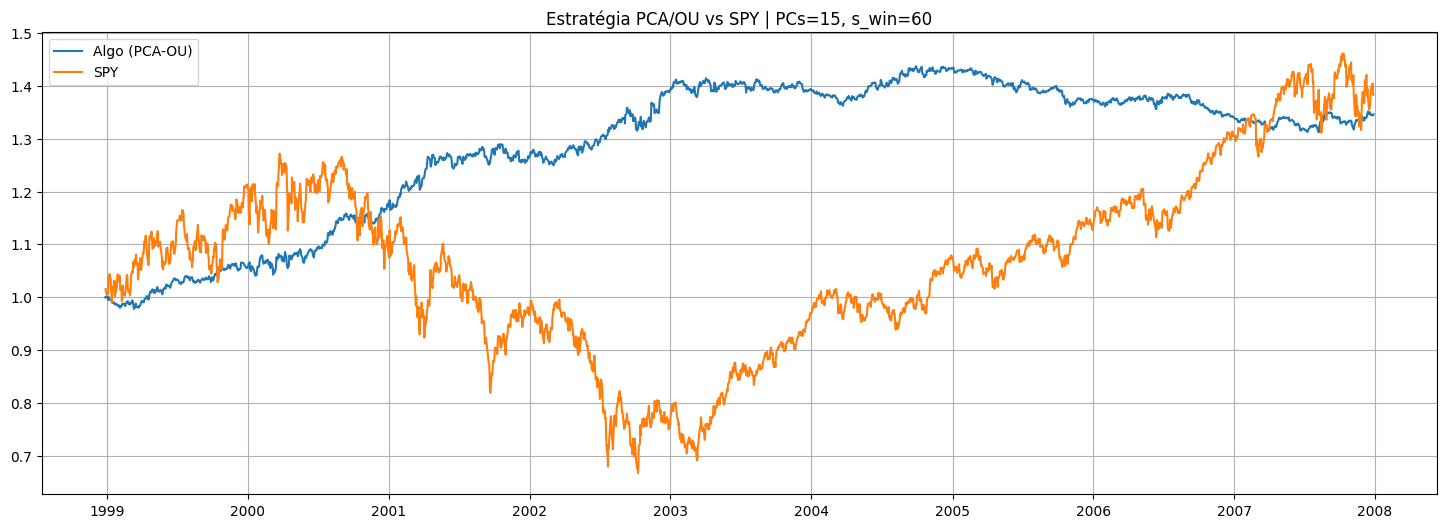

In [8]:
# Rodar experimento 01 : (n = 15, sbo=1.25, sso=1.25, sbc=0.75, ssc=0.50,rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=15,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.75,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [9]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.033635417163771164),
 'Vol': np.float64(0.04551757898734932),
 'Sharpe': np.float64(0.7389544416041863),
 'MaxDD': np.float64(-0.08676683392814144)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    1.001962
1999-01-04    0.998185
                ...   
2007-12-21    1.344870
2007-12-24    1.344160
2007-12-26    1.344486
2007-12-27    1.344096
2007-12-28    1.346103
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

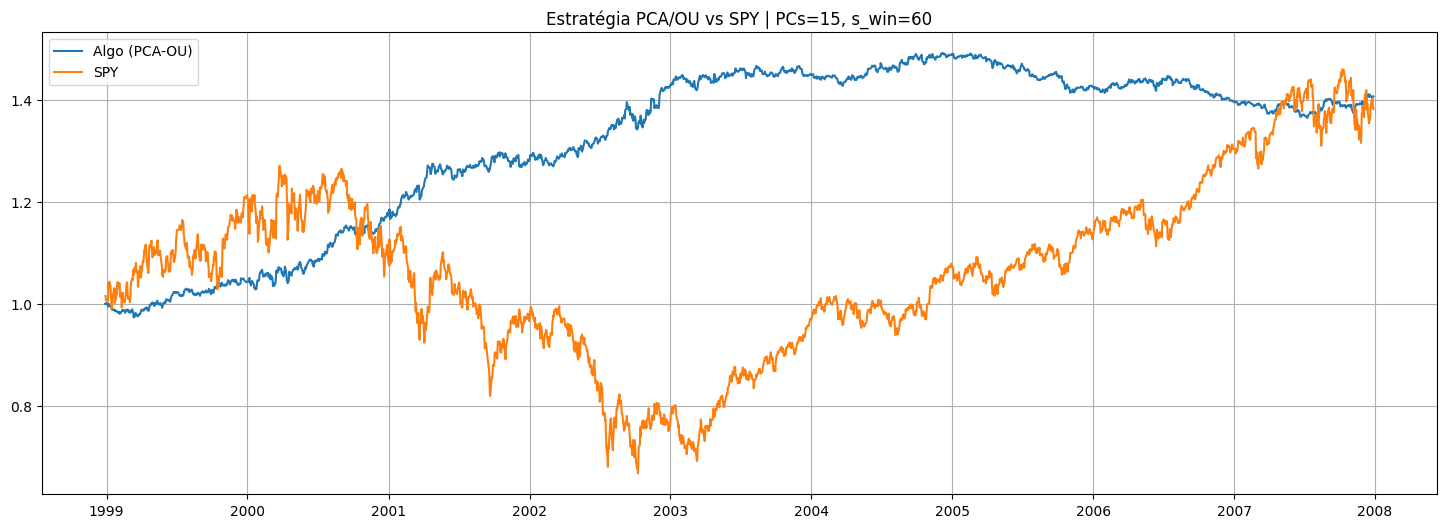

In [10]:
# Rodar experimento 02 : (n = 15, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=15,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [11]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.03879685883662232),
 'Vol': np.float64(0.044545918032023034),
 'Sharpe': np.float64(0.8709408302851037),
 'MaxDD': np.float64(-0.0854754022192794)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    1.001962
1999-01-04    0.998185
                ...   
2007-12-21    1.407344
2007-12-24    1.406796
2007-12-26    1.407616
2007-12-27    1.406757
2007-12-28    1.407710
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

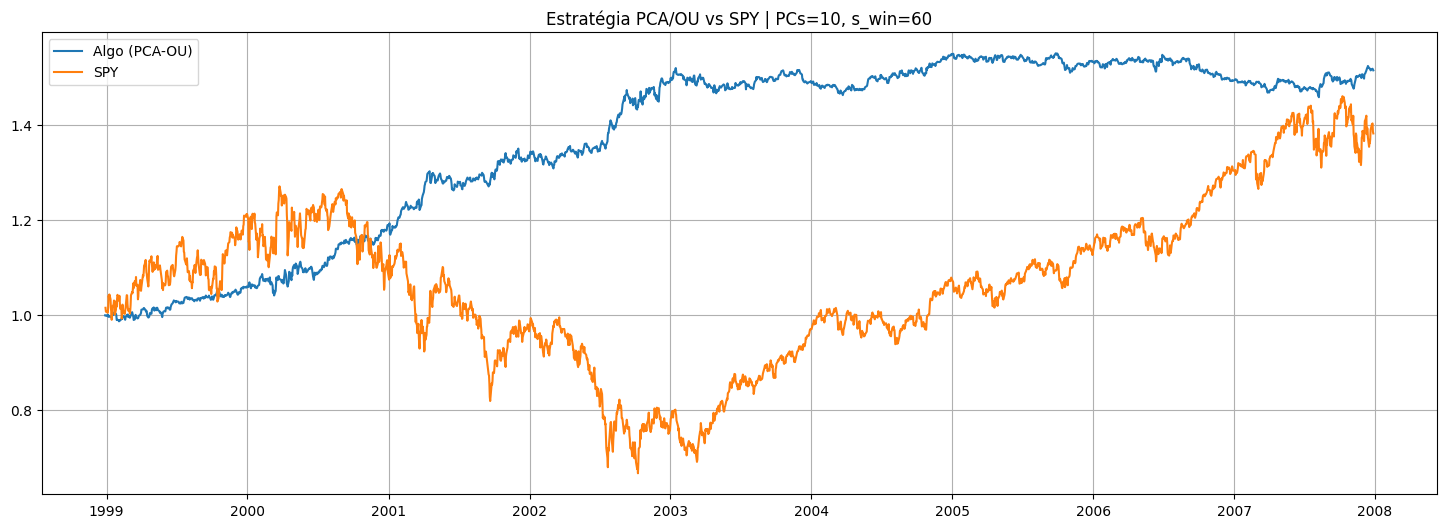

In [12]:
# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [13]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.047386434730483096),
 'Vol': np.float64(0.04896632283787977),
 'Sharpe': np.float64(0.9677352103275664),
 'MaxDD': np.float64(-0.05960445190334318)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    0.998602
1999-01-04    1.000862
                ...   
2007-12-21    1.515757
2007-12-24    1.517998
2007-12-26    1.519271
2007-12-27    1.517668
2007-12-28    1.515805
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

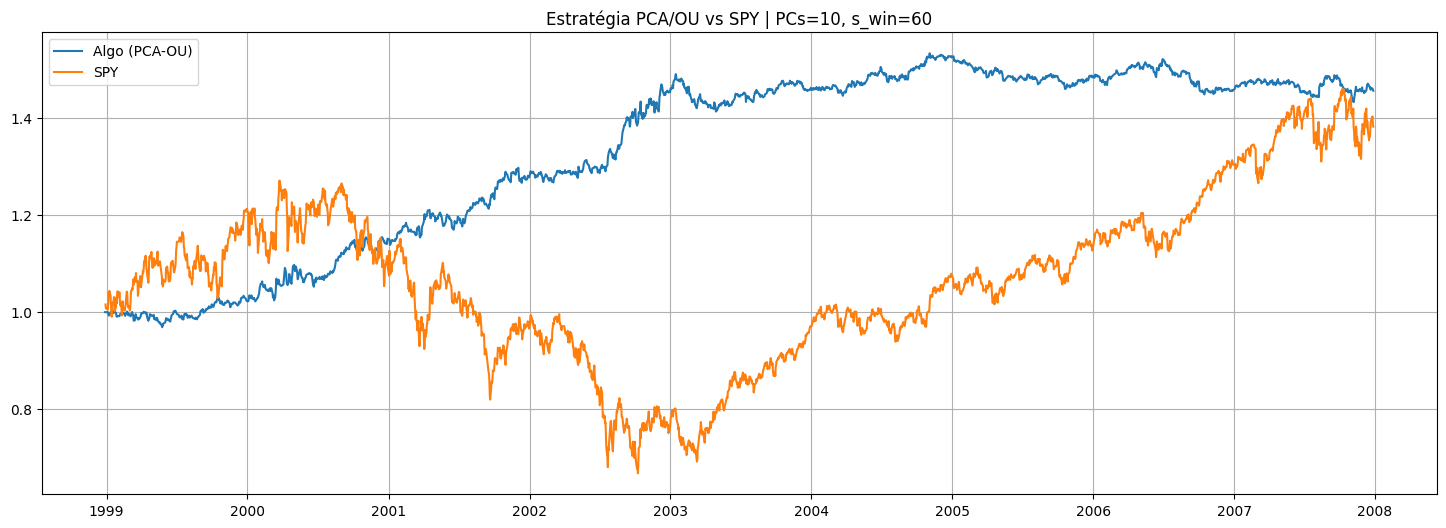

In [14]:
# Rodar experimento 03.2 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 5)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=5,
    plot=True,
)

In [15]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.04278587272994194),
 'Vol': np.float64(0.0510637642956017),
 'Sharpe': np.float64(0.8378910822606009),
 'MaxDD': np.float64(-0.06574040917452673)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    1.000000
1998-12-31    1.000000
1999-01-04    1.000000
                ...   
2007-12-21    1.459101
2007-12-24    1.462373
2007-12-26    1.461682
2007-12-27    1.458705
2007-12-28    1.457026
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

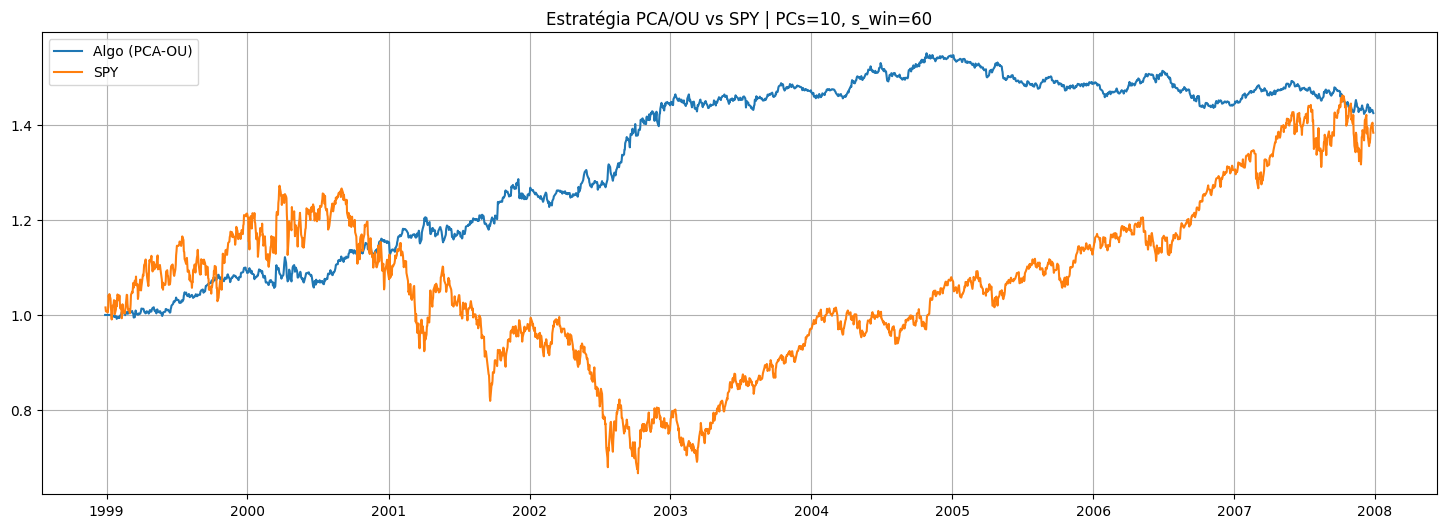

In [16]:
# Rodar experimento 03.3 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 10)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=10,
    plot=True,
)

In [17]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.040145193755595665),
 'Vol': np.float64(0.05276635625994609),
 'Sharpe': np.float64(0.7608104216600814),
 'MaxDD': np.float64(-0.0821836076401391)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    1.000000
1998-12-31    1.000000
1999-01-04    1.000000
                ...   
2007-12-21    1.427456
2007-12-24    1.430932
2007-12-26    1.430176
2007-12-27    1.425529
2007-12-28    1.424211
Length: 2265, dtype: float64

Tempo : 1998-12-28 00:00:00
Tempo : 1998-12-29 00:00:00
Tempo : 1998-12-30 00:00:00
Tempo : 1998-12-31 00:00:00
Tempo : 1999-01-04 00:00:00
Tempo : 1999-01-05 00:00:00
Tempo : 1999-01-06 00:00:00
Tempo : 1999-01-07 00:00:00
Tempo : 1999-01-08 00:00:00
Tempo : 1999-01-11 00:00:00
Tempo : 1999-01-12 00:00:00
Tempo : 1999-01-13 00:00:00
Tempo : 1999-01-14 00:00:00
Tempo : 1999-01-15 00:00:00
Tempo : 1999-01-19 00:00:00
Tempo : 1999-01-20 00:00:00
Tempo : 1999-01-21 00:00:00
Tempo : 1999-01-22 00:00:00
Tempo : 1999-01-25 00:00:00
Tempo : 1999-01-26 00:00:00
Tempo : 1999-01-27 00:00:00
Tempo : 1999-01-28 00:00:00
Tempo : 1999-01-29 00:00:00
Tempo : 1999-02-01 00:00:00
Tempo : 1999-02-02 00:00:00
Tempo : 1999-02-03 00:00:00
Tempo : 1999-02-04 00:00:00
Tempo : 1999-02-05 00:00:00
Tempo : 1999-02-08 00:00:00
Tempo : 1999-02-09 00:00:00
Tempo : 1999-02-10 00:00:00
Tempo : 1999-02-11 00:00:00
Tempo : 1999-02-12 00:00:00
Tempo : 1999-02-16 00:00:00
Tempo : 1999-02-17 00:00:00
Tempo : 1999-02-18 0

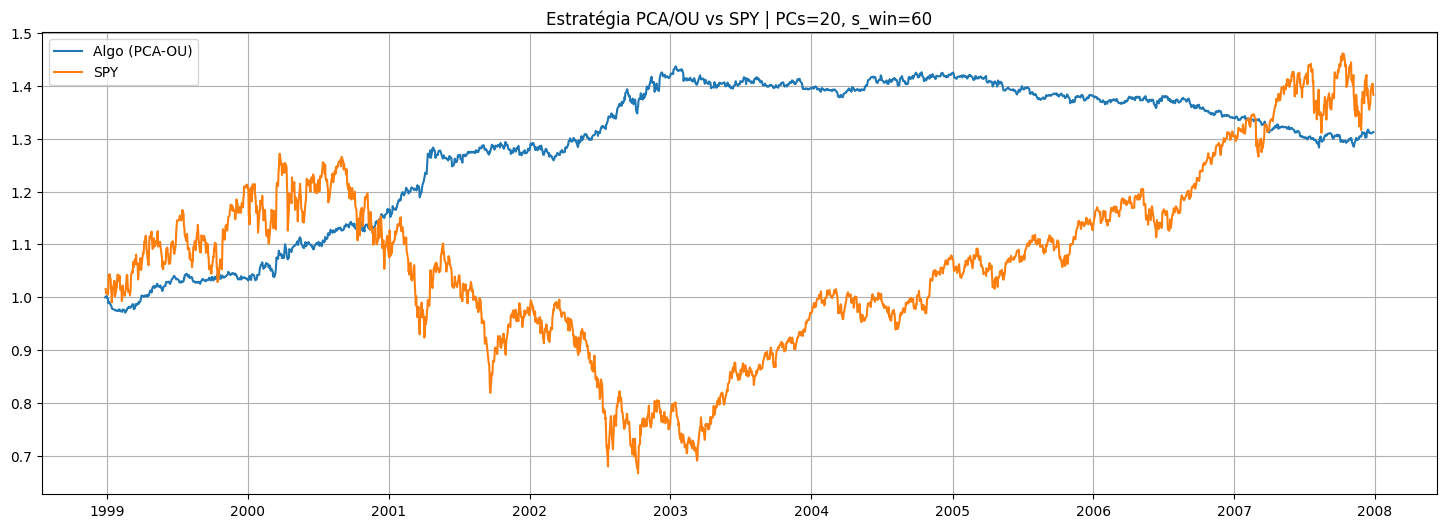

In [18]:
# Rodar experimento 04 : (n = 20, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50, rebalanceamento_dias = 1)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=20,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
)

In [19]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.030729058366903317),
 'Vol': np.float64(0.04087328197471134),
 'Sharpe': np.float64(0.7518128440460362),
 'MaxDD': np.float64(-0.10690788245055038)}

Date
1998-12-28    1.000000
1998-12-29    1.000000
1998-12-30    0.999500
1998-12-31    1.002474
1999-01-04    0.997021
                ...   
2007-12-21    1.310017
2007-12-24    1.310489
2007-12-26    1.312080
2007-12-27    1.311995
2007-12-28    1.312478
Length: 2265, dtype: float64

In [ ]:
#pip install quantstats

In [ ]:
import quantstats as qs

qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
